In [5]:
import pandas as pd
import numpy as np
import os
# working dir
work_path = "C:/Users/wenlou/Documents/Python Scripts"
data_path = "P:/3026008.01/Data/"
pred_path = 'C:/Users/wenlou/Documents/MATLAB/Prediction'
os.chdir(work_path)
from help_function import *

#read subject list     
sub_id_lst = read_sub_lst()

#############################
#sub_id_lst = sub_group_lst(m_id)
fontsize = 16

######  BEH 
df_beh = processBehDat()

#########Model Prediction
df_sim_bay = processPredDat(70, sub_id_lst)
df_sim_bay = df_sim_bay.loc[df_sim_bay['tr_f'] == 1, :].copy()
df_sim_xd = processPredDat(74, sub_id_lst)
df_sim_xd = df_sim_xd.loc[df_sim_xd['tr_f'] == 1, :].copy()


In [6]:
df_beh.loc[:, 'abs_del_VA'] = df_beh.loc[:, 'delta_VA'].abs()
df_sim_bay.loc[:, 'abs_del_VA'] = df_sim_bay.loc[:, 'delta_VA'].abs()
df_sim_xd.loc[:, 'abs_del_VA'] = df_sim_xd.loc[:, 'delta_VA'].abs()
df_sim_bay.rename(columns={'R_conf': 'confLvl'}, inplace=True)
df_sim_xd.rename(columns={'R_conf': 'confLvl'}, inplace=True)

In [3]:
df_beh

,sub_id,delta_VA,confLvl,ComSourLbl,ComSourFlag,s_a,s_v,ConfLbl,abs_del_VA
0,1,-8,2,Separate,2,4,-4,Medium,8
1,1,8,2,Common,1,4,12,Medium,8
2,1,-16,2,Separate,2,4,-12,Medium,16
3,1,-8,2,Separate,2,-4,-12,Medium,8
4,1,0,2,Common,1,-4,-4,Medium,0
...,...,...,...,...,...,...,...,...,...
8699,45,-24,3,Separate,2,12,-12,High,24
8700,45,-16,3,Separate,2,12,-4,High,16
8701,45,0,3,Common,1,12,12,High,0
8702,45,-16,3,Separate,2,12,-4,High,16


In [4]:
df_sim_bay

,prob,rec,s_a,s_v,s_uni,tr_f,R_pc,confLvl,R_s,sub_id,delta_VA,ComSourLbl,ConfLbl,abs_del_VA
0,0.580186,-1.879864,-12,-12,-12,1,1,1,-12,1,0,Common,Low,0
1,0.536401,-5.097822,-12,-12,-12,1,1,1,-12,1,0,Common,Low,0
2,0.608125,11.105156,-12,-12,-12,1,1,2,-4,1,0,Common,Medium,0
3,0.850902,-2.021489,-12,-12,-12,1,1,3,-12,1,0,Common,High,0
4,0.854620,1.291415,-12,-12,-12,1,1,3,-12,1,0,Common,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738235,0.710820,-0.894826,12,12,12,1,1,3,4,45,0,Common,High,0
1738236,0.649416,3.210309,12,12,12,1,1,3,12,45,0,Common,High,0
1738237,0.679010,-8.050704,12,12,12,1,1,3,4,45,0,Common,High,0
1738238,0.727443,-0.273031,12,12,12,1,1,3,4,45,0,Common,High,0


In [7]:
def compute_ratio(df, name, prop_total=False):
    df_count=df.groupby(["abs_del_VA", "ConfLbl"]).size().reset_index(name="n").pivot(index=["abs_del_VA"], columns="ConfLbl", values="n").fillna(0).reset_index()
    df_count.loc[:, 'sum'] = df_count.loc[:, 'High'] + df_count.loc[:, 'Medium']  + df_count.loc[:, 'Low']
    df_count.loc[:,'total_sum'] = df_count.loc[:, 'sum'].sum()
    if prop_total:
        df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:,'total_sum']
        df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:,'total_sum']
        df_count.loc[:, 'Low'] = df_count.loc[:, 'Low'] / df_count.loc[:,'total_sum']
    else:
        df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
        df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
        df_count.loc[:, 'Low'] = df_count.loc[:, 'Low'] / df_count.loc[:, 'sum']
    df_count.loc[:, 'Name'] = name
    return df_count

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.37248592 0.4995046  0.76309564 0.88291552]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.36202735 0.28676575 0.16018925 0.08462542]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.26548673 0

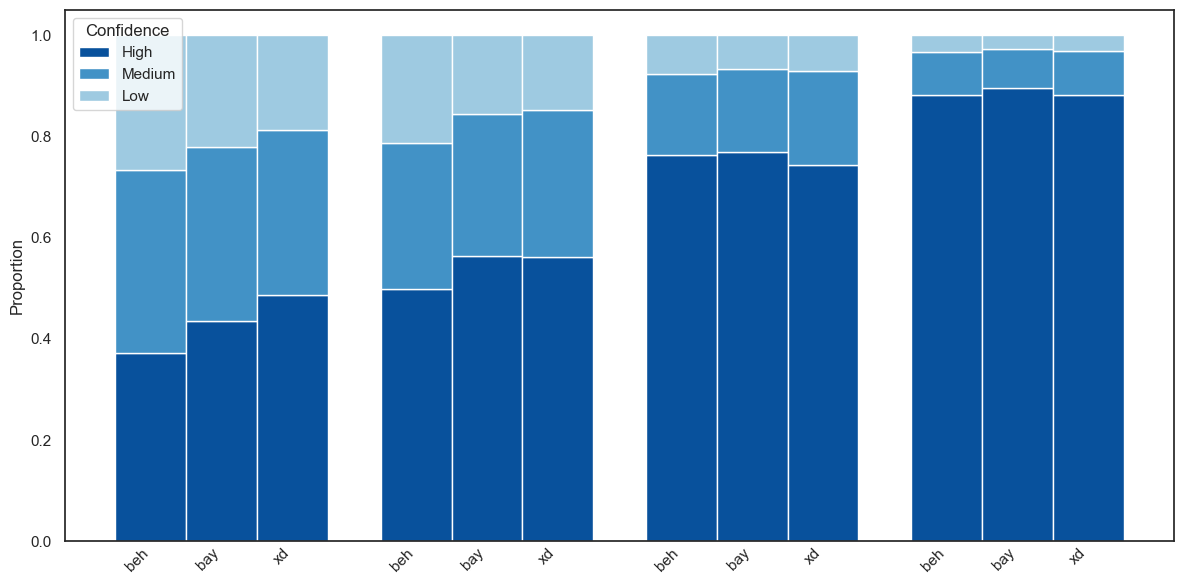

In [9]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}
df1 = compute_ratio(df_beh.loc[(df_beh['ComSourFlag']==2)], 'beh', prop_total=False)
df2 = compute_ratio(df_sim_bay.loc[(df_sim_bay['R_pc']==2)], 'bay', prop_total=False)
df3 = compute_ratio(df_sim_xd.loc[(df_sim_xd['R_pc']==2)], 'xd', prop_total=False)

df_count = pd.concat([df1, df2, df3], axis=0)
df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

categories = df_count['abs_del_VA'].unique()
confidence = ['High', 'Medium', 'Low']

x = np.arange(len(categories))
width = 0.8 / len(names)


fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(names):

    subset = df_count[df_count['Name'] == name]

    bottom = np.zeros(len(categories))

    for conf in confidence:

        values = (
            subset[subset['ConfLbl'] == conf]
            .set_index('abs_del_VA')
            .reindex(categories)['prop']
            .fillna(0)
            .values
        )

        ax.bar(
            x + (i - (len(names)-1)/2) * width,
            values,
            width,
            bottom=bottom,
            color=colors[conf],
            label=conf if i == 0 else None
        )

        bottom += values

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_xlabel('')
ax.set_ylabel('Proportion')

ax.legend(title='Confidence')
tick_positions = []
tick_labels = []

for i, name in enumerate(names):
    positions = x + (i - (len(names)-1)/2) * width
    
    tick_positions.extend(positions)
    tick_labels.extend([name] * len(categories))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
#clean_axs(ax)
ax.tick_params(axis='x', direction='in')

plt.tight_layout()
#plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_dist_{sub_id}.png"), dpi=300)
plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.70462506 0.63365647 0.5565371  0.43636364]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.23768675 0.26712285 0.27885748 0.28531469]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.05768818 0

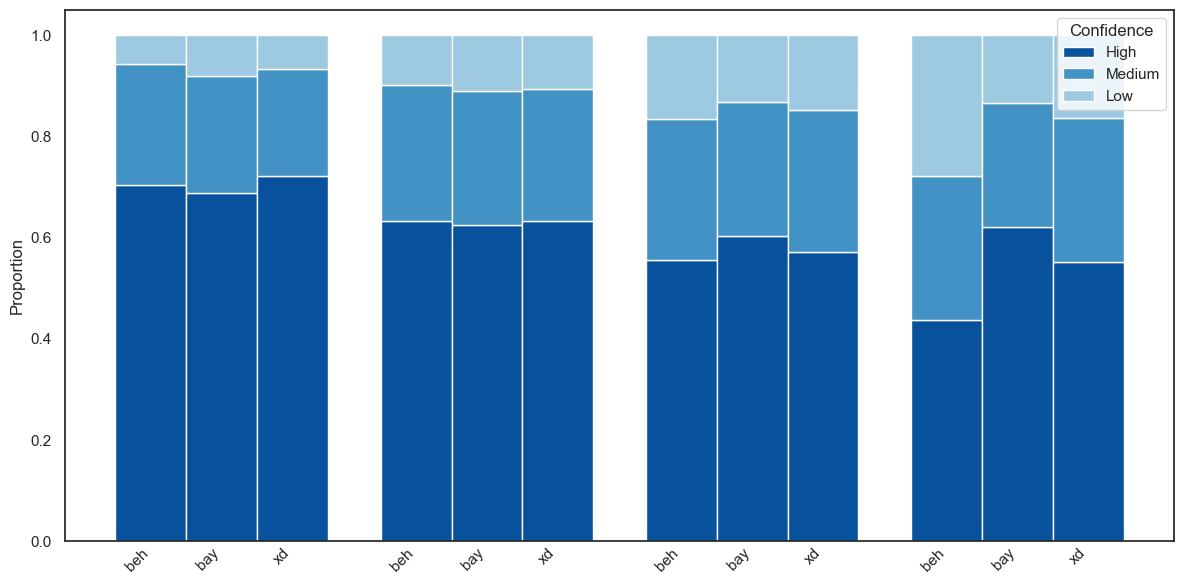

In [10]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}
df1 = compute_ratio(df_beh.loc[(df_beh['ComSourFlag']==1)], 'beh', prop_total=False)
df2 = compute_ratio(df_sim_bay.loc[(df_sim_bay['R_pc']==1)], 'bay', prop_total=False)
df3 = compute_ratio(df_sim_xd.loc[(df_sim_xd['R_pc']==1)], 'xd', prop_total=False)

df_count = pd.concat([df1, df2, df3], axis=0)
df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

categories = df_count['abs_del_VA'].unique()
confidence = ['High', 'Medium', 'Low']

x = np.arange(len(categories))
width = 0.8 / len(names)


fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(names):

    subset = df_count[df_count['Name'] == name]

    bottom = np.zeros(len(categories))

    for conf in confidence:

        values = (
            subset[subset['ConfLbl'] == conf]
            .set_index('abs_del_VA')
            .reindex(categories)['prop']
            .fillna(0)
            .values
        )

        ax.bar(
            x + (i - (len(names)-1)/2) * width,
            values,
            width,
            bottom=bottom,
            color=colors[conf],
            label=conf if i == 0 else None
        )

        bottom += values

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_xlabel('')
ax.set_ylabel('Proportion')

ax.legend(title='Confidence')
tick_positions = []
tick_labels = []

for i, name in enumerate(names):
    positions = x + (i - (len(names)-1)/2) * width
    
    tick_positions.extend(positions)
    tick_labels.extend([name] * len(categories))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
#clean_axs(ax)
ax.tick_params(axis='x', direction='in')

plt.tight_layout()
#plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_dist_{sub_id}.png"), dpi=300)
plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.67752101 0.59217437 0.71704307 0.84099265]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.24783351 0.27319678 0.18664653 0.10346639]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.07464548 0.13462

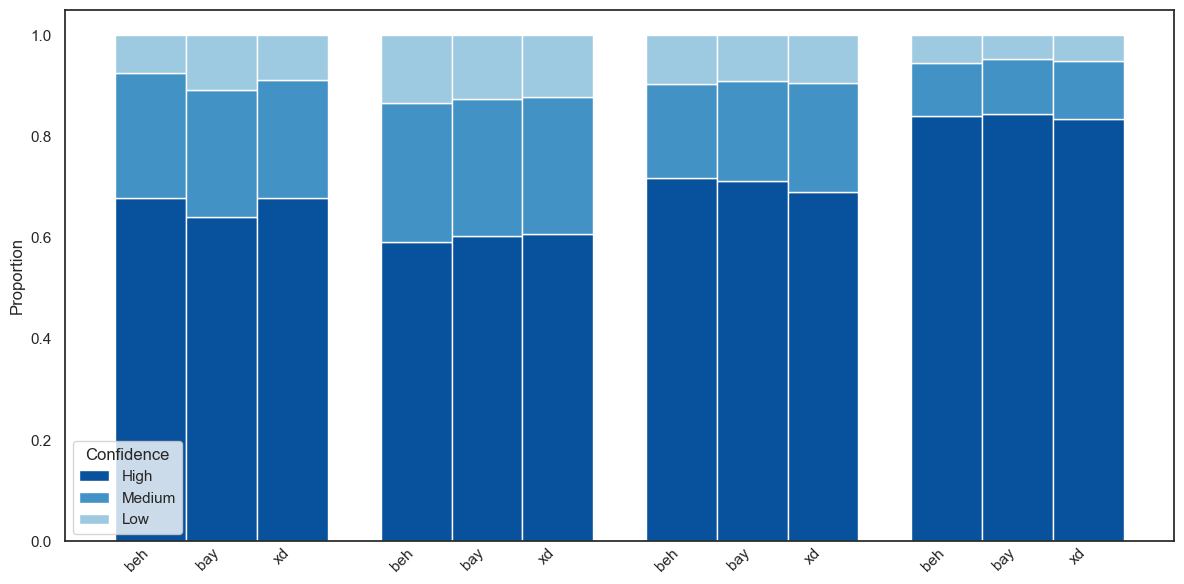

In [4]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}
df1 = compute_ratio(df_beh, 'beh', prop_total=False)
df2 = compute_ratio(df_sim_bay, 'bay', prop_total=False)
df3 = compute_ratio(df_sim_xd, 'xd', prop_total=False)

df_count = pd.concat([df1, df2, df3], axis=0)
df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

categories = df_count['abs_del_VA'].unique()
confidence = ['High', 'Medium', 'Low']

x = np.arange(len(categories))
width = 0.8 / len(names)


fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(names):

    subset = df_count[df_count['Name'] == name]

    bottom = np.zeros(len(categories))

    for conf in confidence:

        values = (
            subset[subset['ConfLbl'] == conf]
            .set_index('abs_del_VA')
            .reindex(categories)['prop']
            .fillna(0)
            .values
        )

        ax.bar(
            x + (i - (len(names)-1)/2) * width,
            values,
            width,
            bottom=bottom,
            color=colors[conf],
            label=conf if i == 0 else None
        )

        bottom += values

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_xlabel('')
ax.set_ylabel('Proportion')

ax.legend(title='Confidence')
tick_positions = []
tick_labels = []

for i, name in enumerate(names):
    positions = x + (i - (len(names)-1)/2) * width
    
    tick_positions.extend(positions)
    tick_labels.extend([name] * len(categories))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
#clean_axs(ax)
ax.tick_params(axis='x', direction='in')

plt.tight_layout()
#plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_dist_{sub_id}.png"), dpi=300)
plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.79890625 0.72       0.904375   0.996875  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.1396875 0.1953125 0.0684375 0.0021875]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.06140625 0.084687

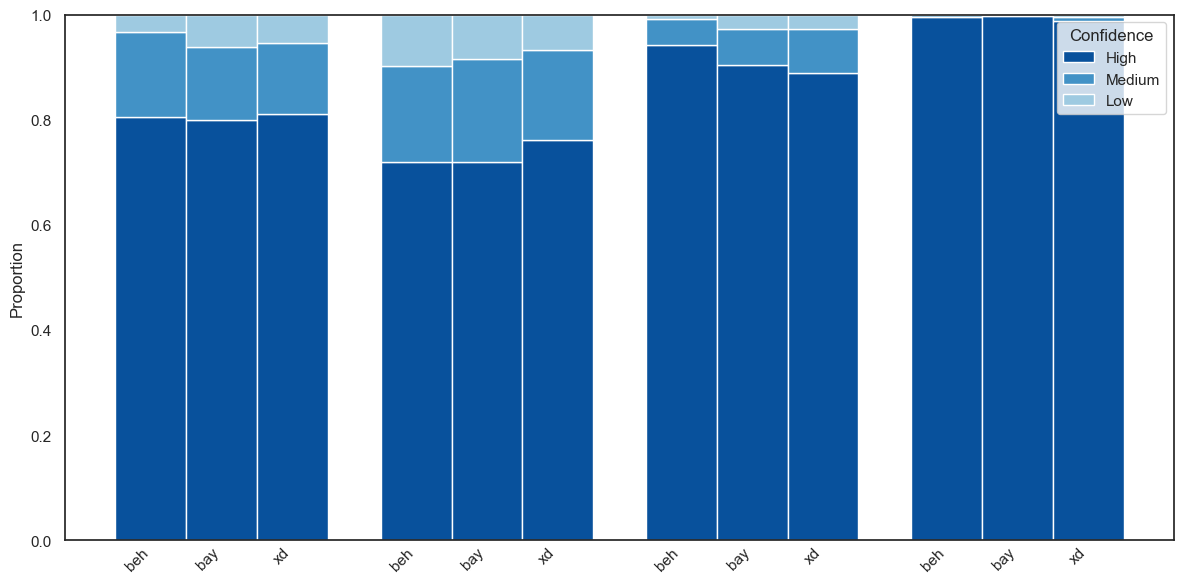

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.77678571 0.75       0.61383929 0.61607143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.17857143 0.2172619  0.29464286 0.29017857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.04464286 0.03

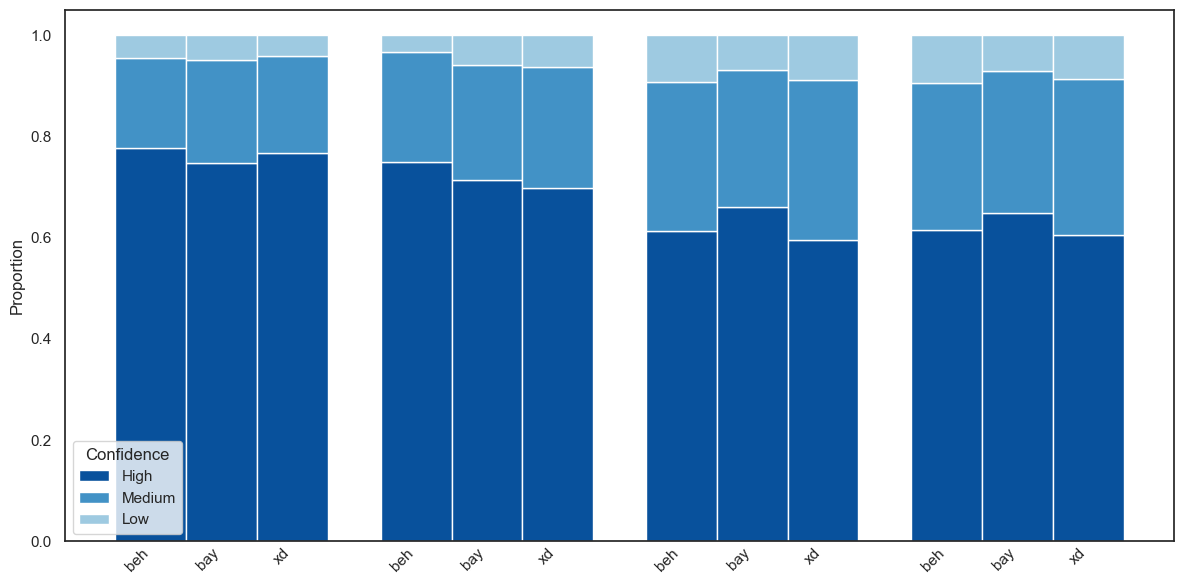

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.71651786 0.56547619 0.703125   0.9375    ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.26339286 0.3452381  0.234375   0.05803571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02008929 0.08

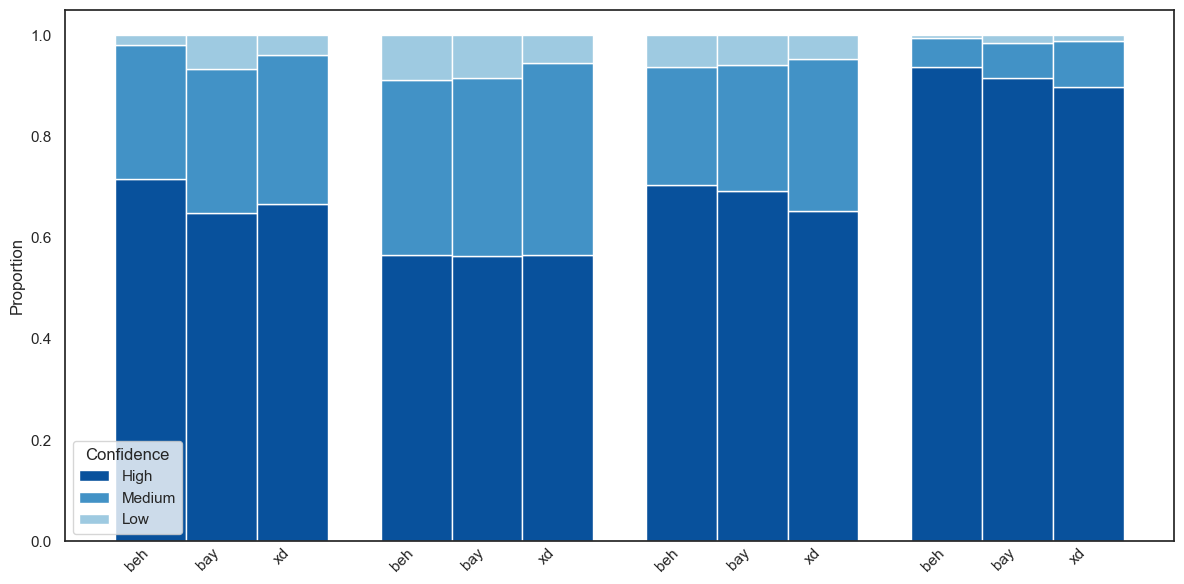

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4334375  0.3671875  0.66109375 0.944375  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.3590625 0.3715625 0.199375  0.03625  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.2075     0.26125 

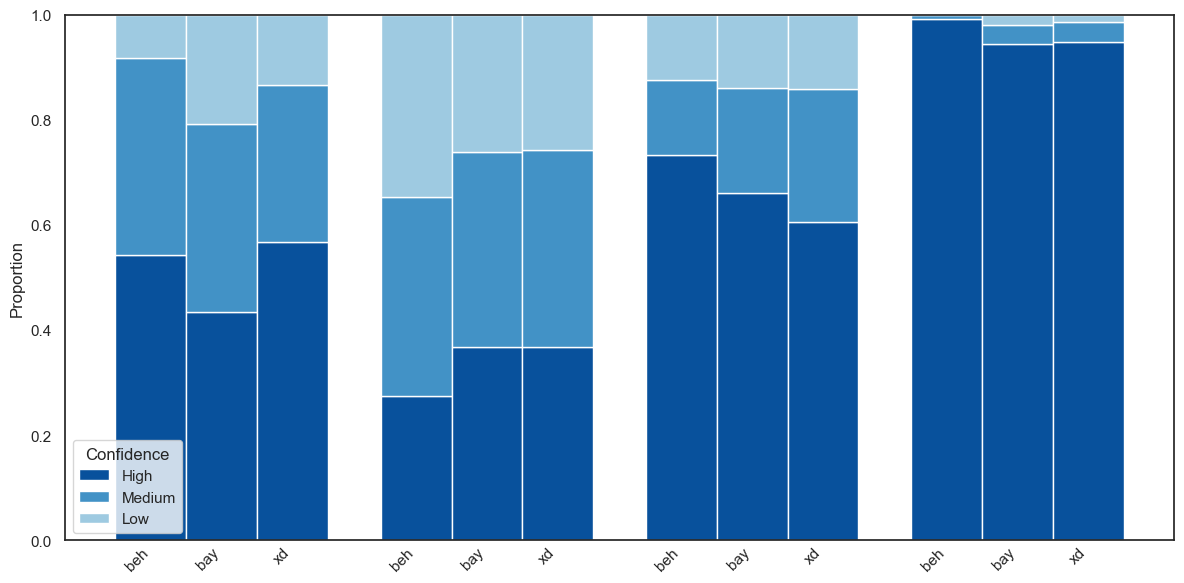

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11171875 0.15489583 0.50234375 0.874375  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.79703125 0.72677083 0.42734375 0.113125  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.09125    0.11

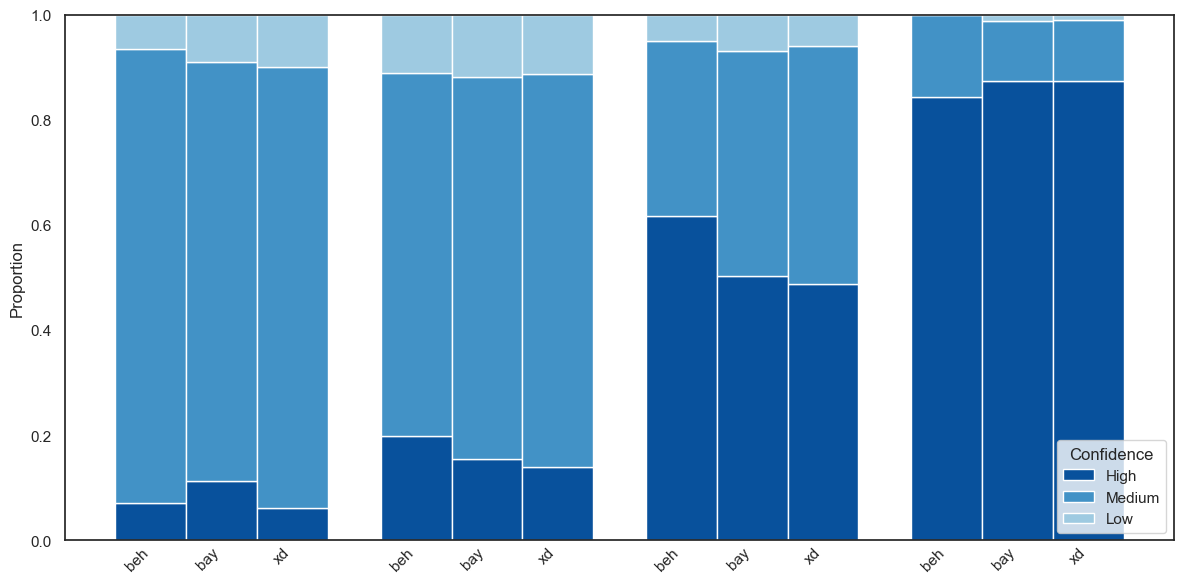

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.86607143 0.82440476 0.80580357 0.83482143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.12053571 0.13244048 0.13169643 0.09821429]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01339286 0.04

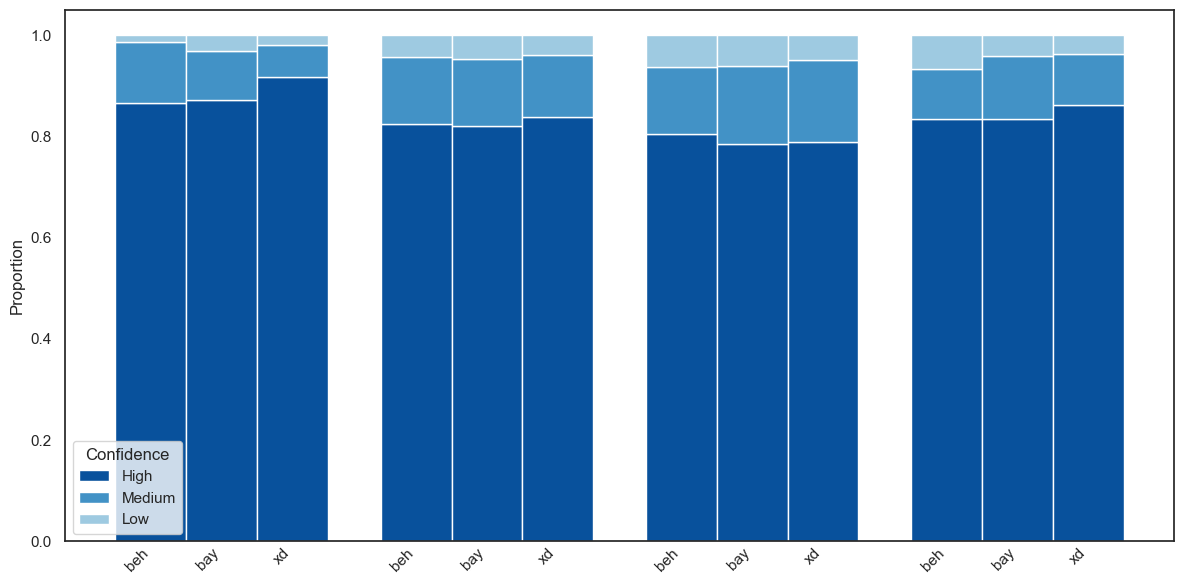

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.81919643 0.75446429 0.63392857 0.77232143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.15401786 0.18154762 0.25223214 0.16517857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02678571 0.06

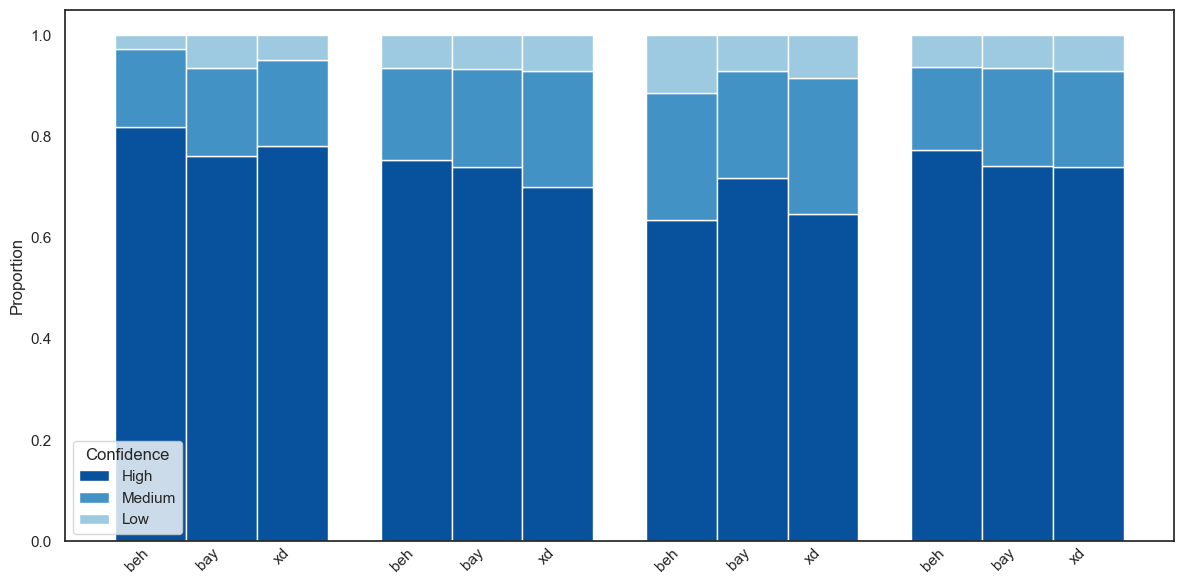

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.73046875 0.74135417 0.77140625 0.8040625 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.24703125 0.23708333 0.20859375 0.1825    ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0225    0.021

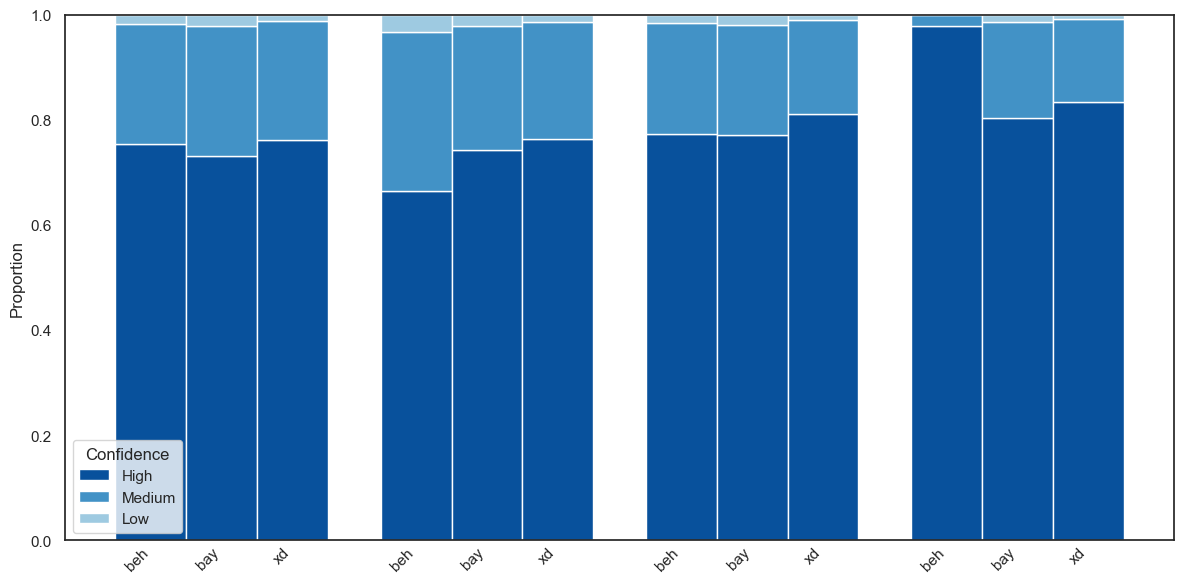

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.885625   0.529375   0.54421875 0.9734375 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.10171875 0.31177083 0.270625   0.0196875 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01265625 0.15

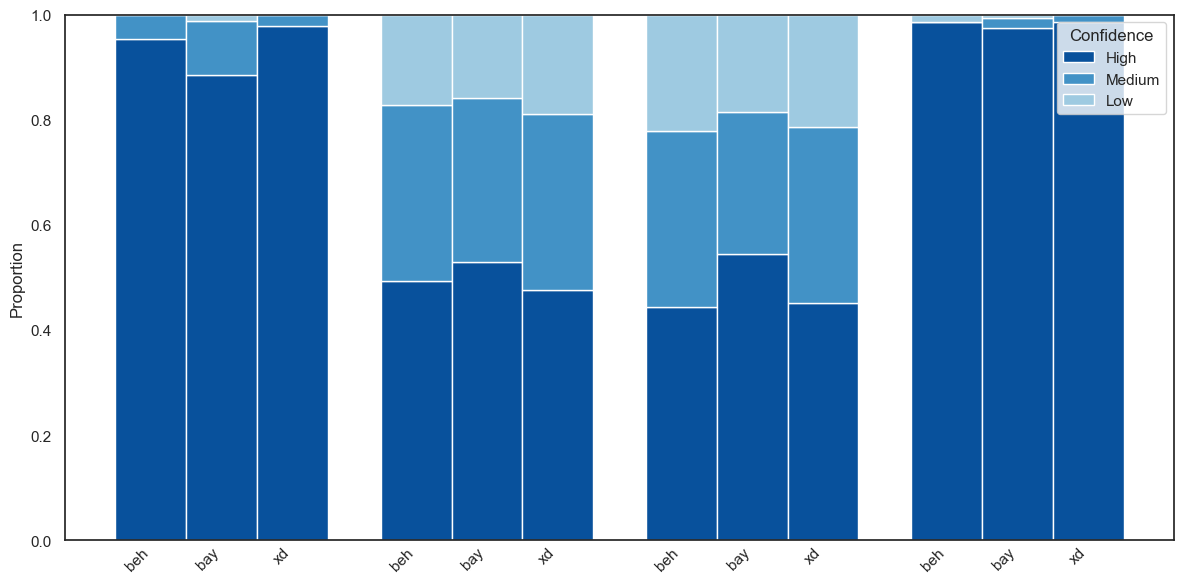

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.52901786 0.32886905 0.62053571 0.90178571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.35714286 0.38392857 0.16294643 0.08035714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11383929 0.28

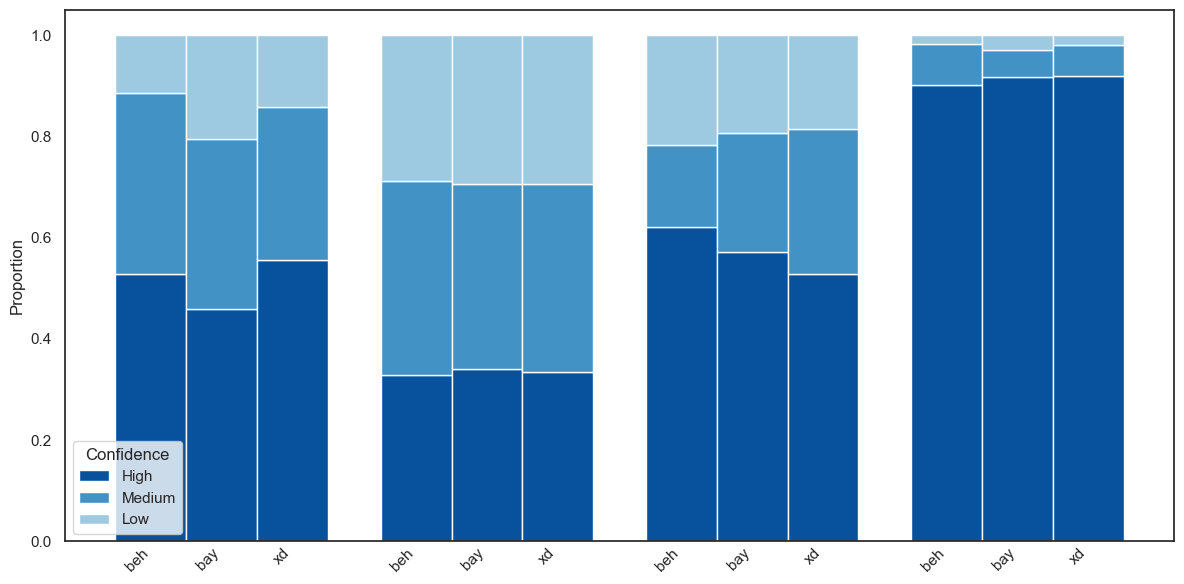

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.93526786 0.70089286 0.87053571 0.98214286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0625     0.28125    0.12053571 0.01339286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.00223214 0.01

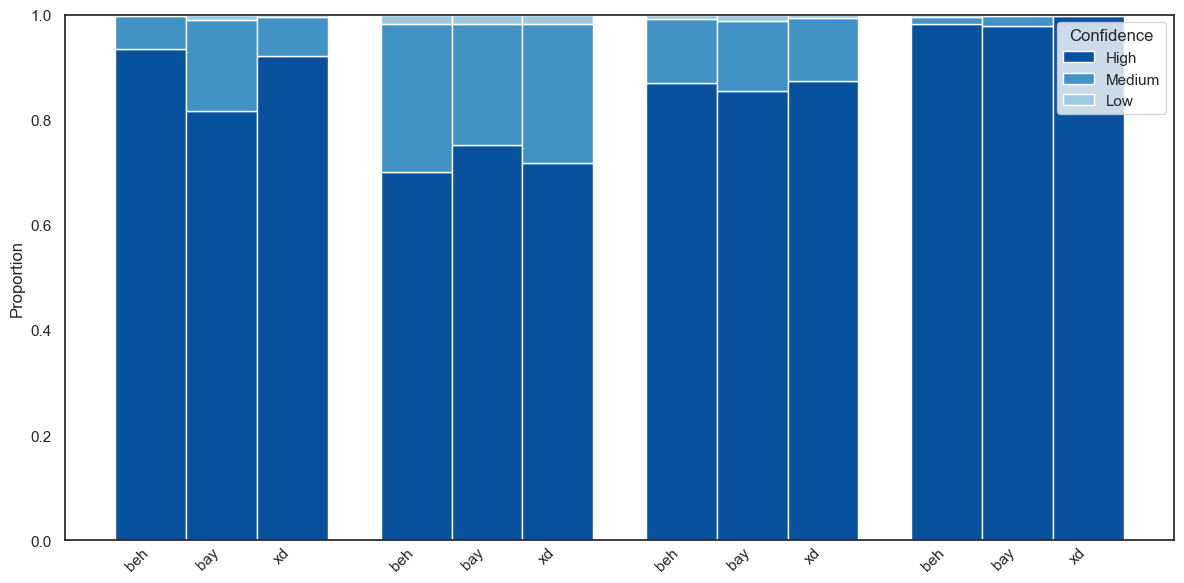

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11607143 0.10267857 0.36160714 0.63839286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.44866071 0.45386905 0.27008929 0.10714286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.43526786 0.44

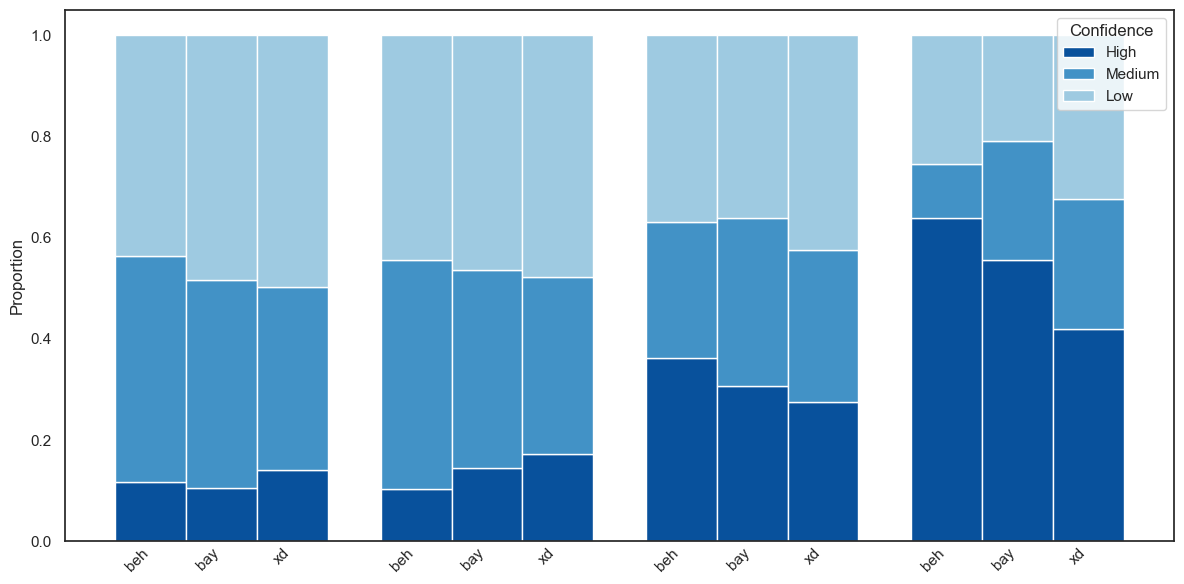

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.46651786 0.36458333 0.38616071 0.65178571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.32589286 0.35119048 0.296875   0.17410714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.20758929 0.28

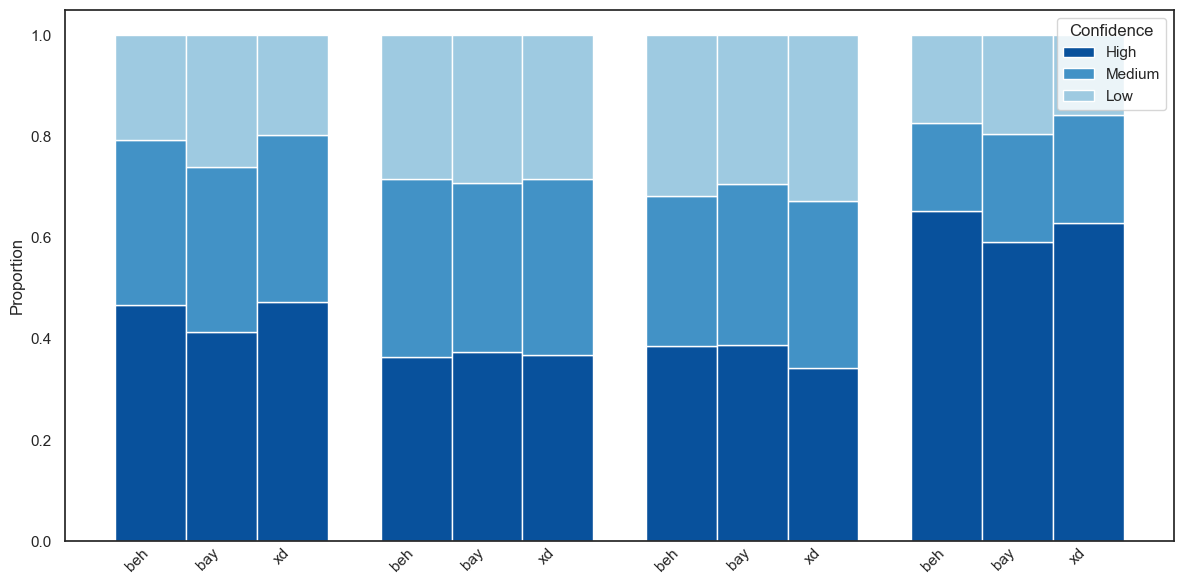

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.50446429 0.66666667 0.49553571 0.00892857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.03348214 0.01488095 0.03125    0.04017857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.46205357 0.31

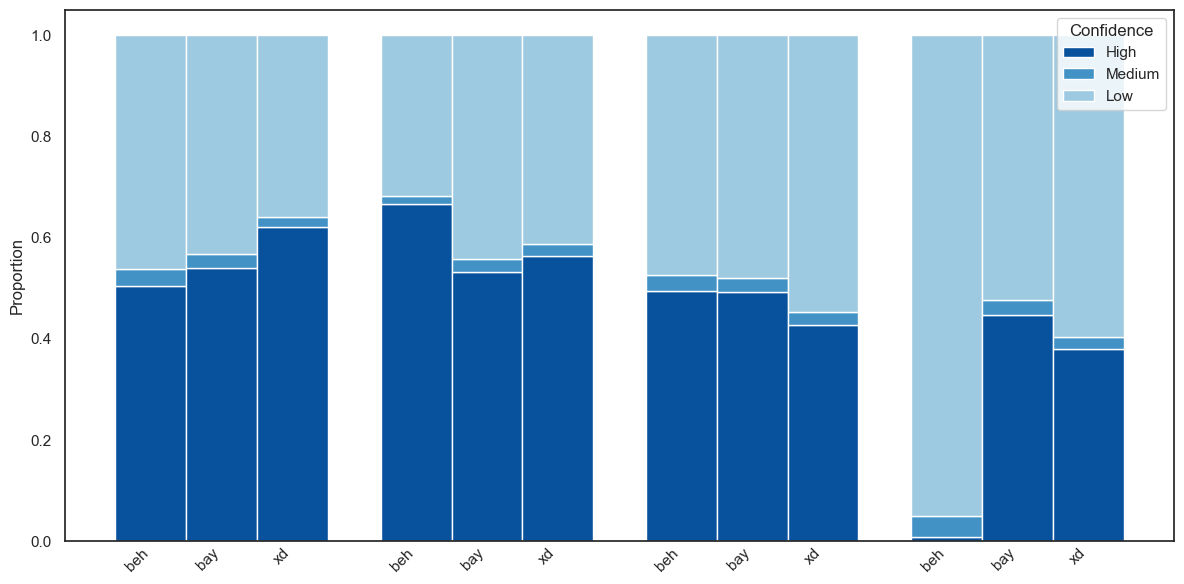

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.859375   0.81994048 0.85044643 0.91517857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.12053571 0.11607143 0.11383929 0.07142857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02008929 0.06

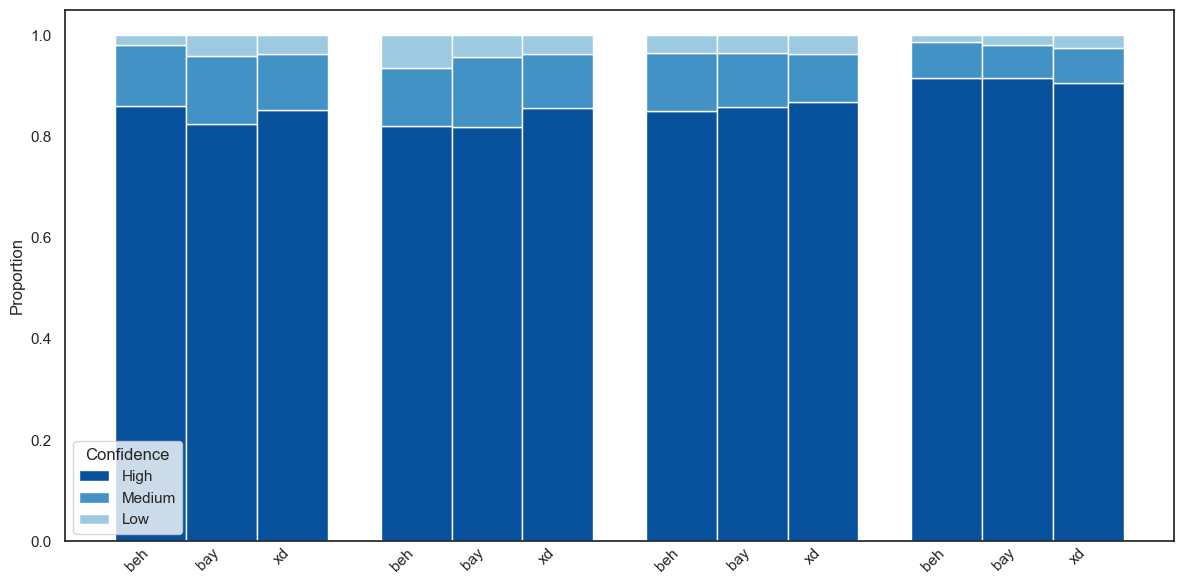

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.55375    0.563125   0.75234375 0.9371875 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.32796875 0.319375   0.18140625 0.0496875 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11828125 0.11

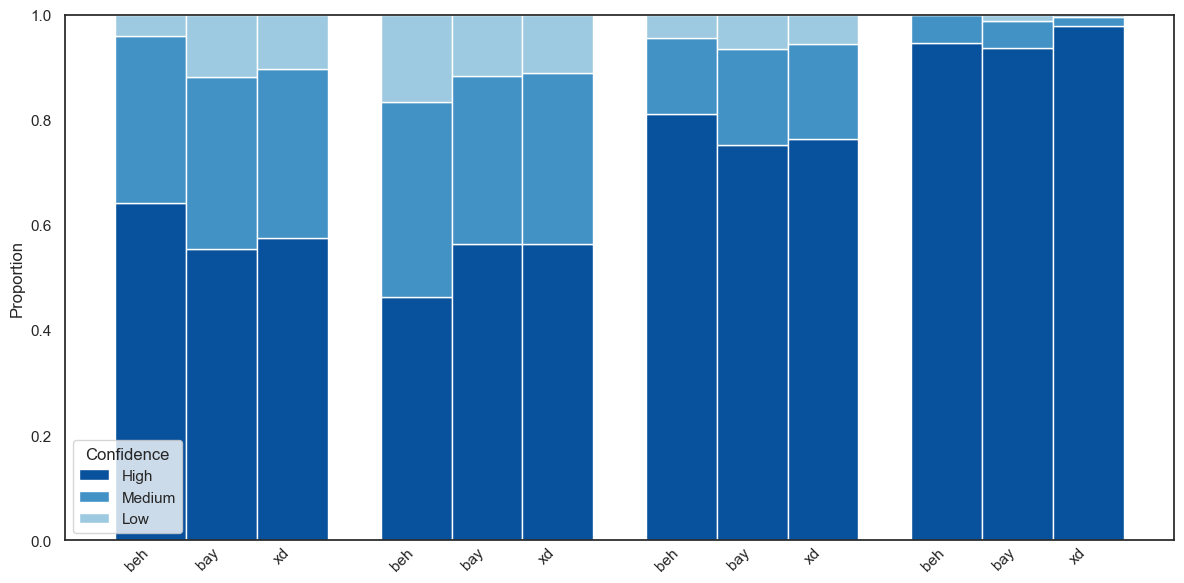

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4659375  0.44229167 0.77234375 0.97875   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.26453125 0.26       0.11265625 0.0134375 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.26953125 0.29

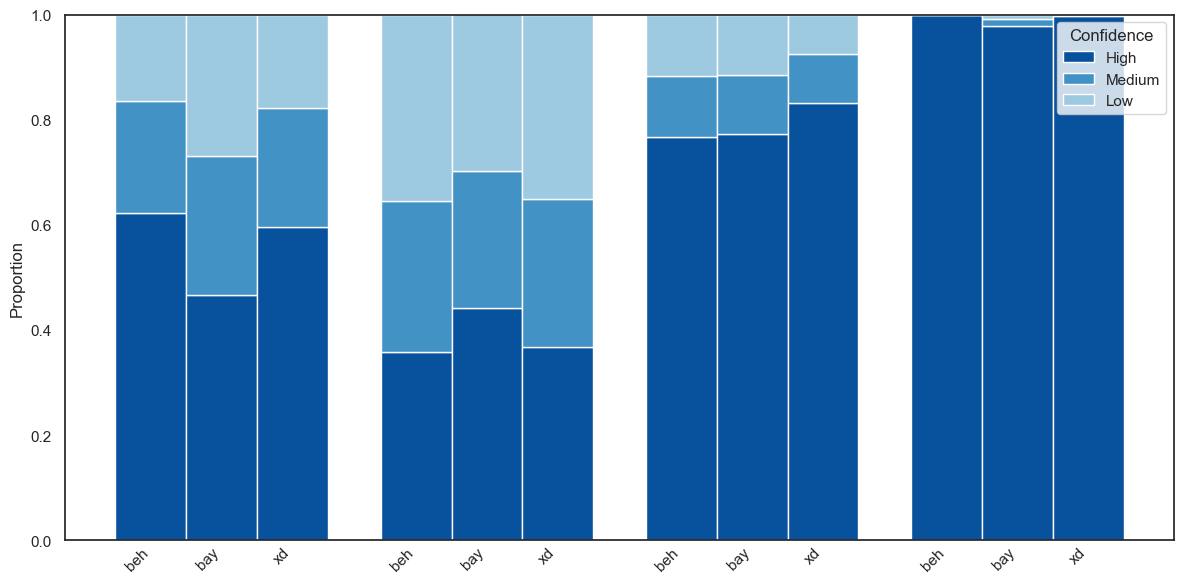

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.84598214 0.80208333 0.79464286 0.95982143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.09598214 0.08928571 0.06919643 0.02232143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.05803571 0.10

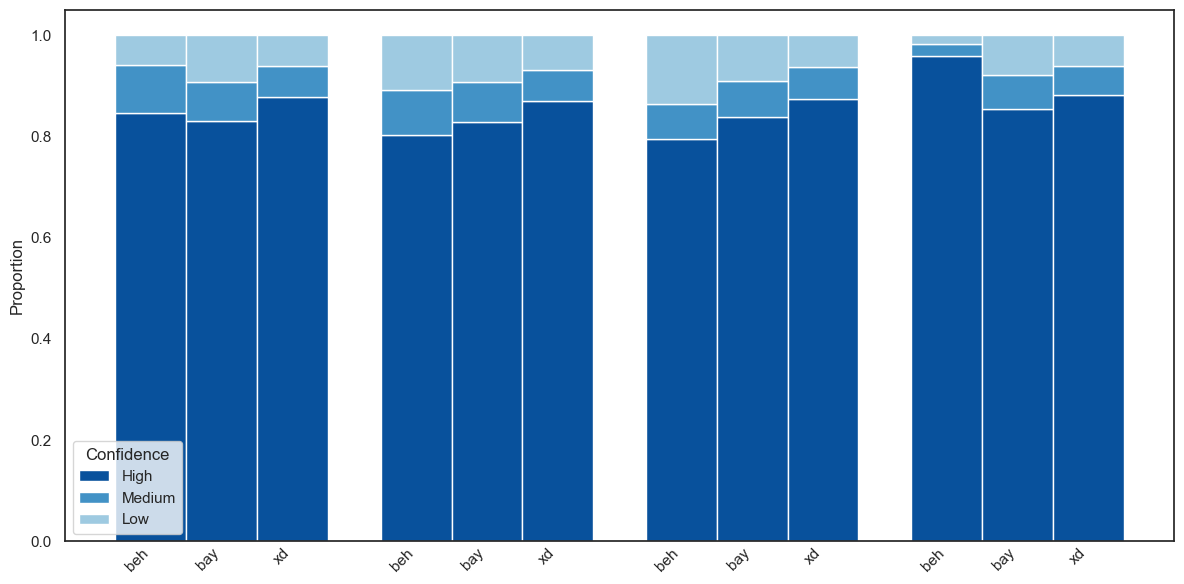

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.791875   0.75958333 0.94015625 0.9984375 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.13703125 0.15291667 0.03859375 0.00125   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.07109375 0.08

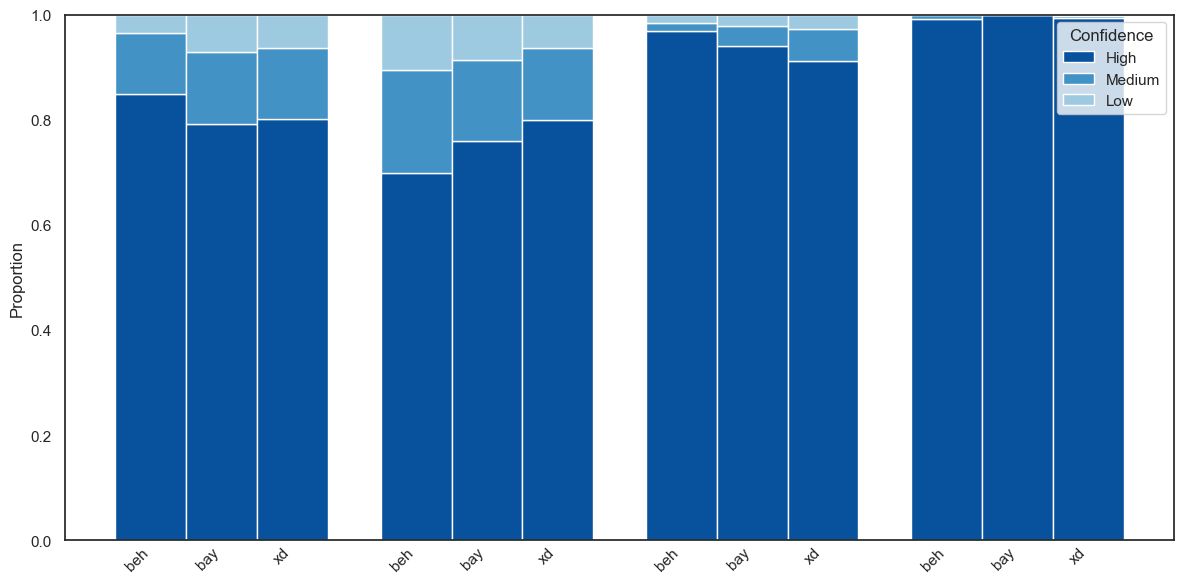

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.9375     0.89285714 0.75223214 0.70982143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.06026786 0.09375    0.22544643 0.23214286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.00223214 0.01

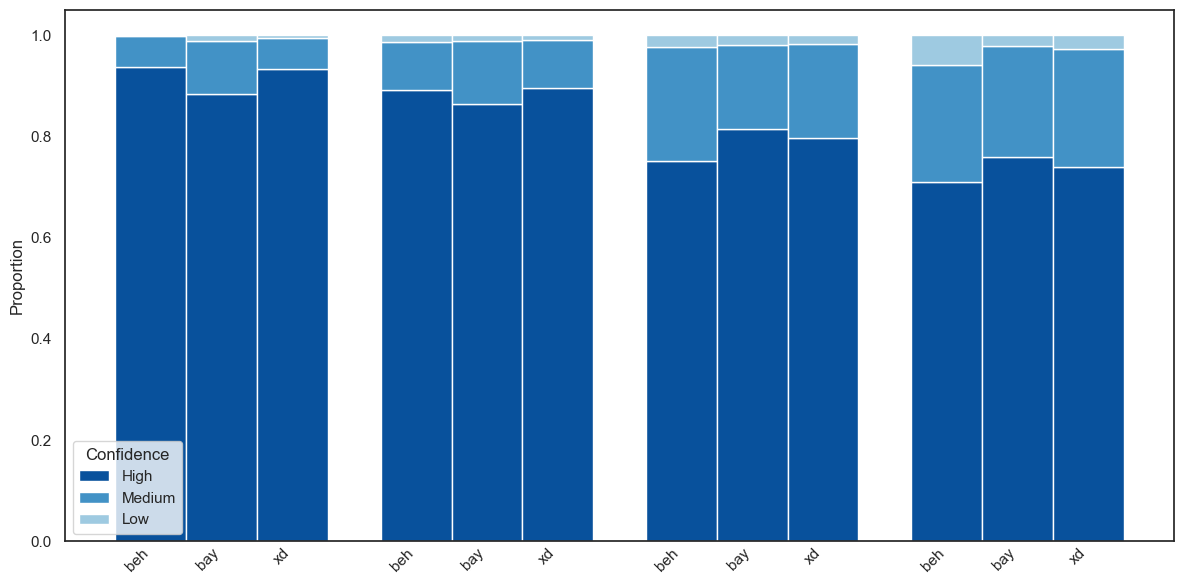

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.355      0.46770833 0.80484375 0.973125  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.5009375  0.40979167 0.1509375  0.02125   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.1440625  0.12

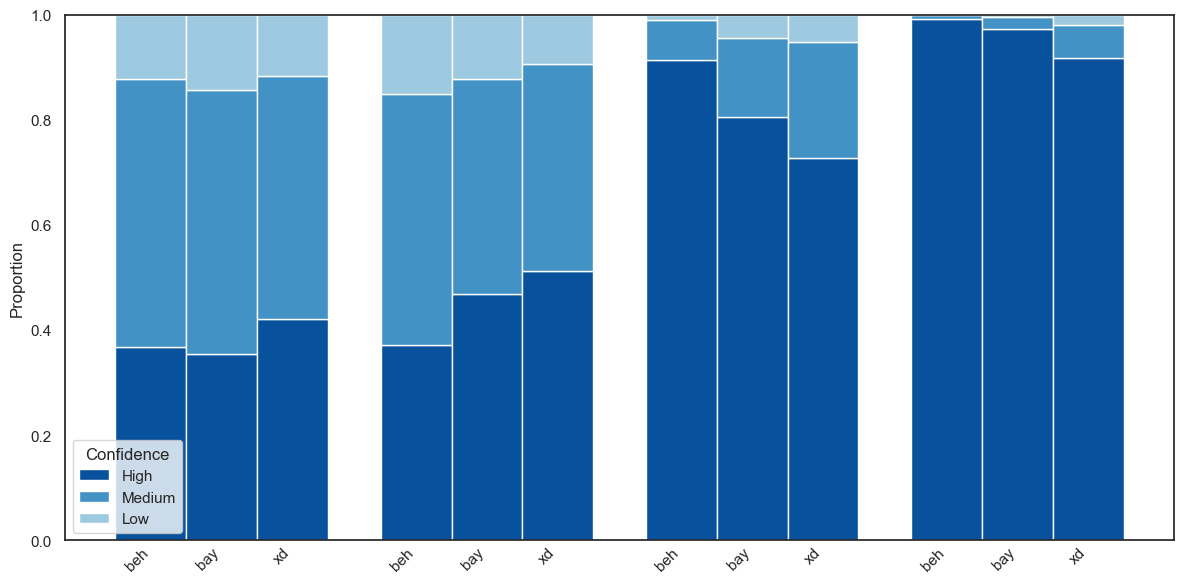

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.8025     0.81614583 0.93578125 0.99375   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.17875    0.16604167 0.05875    0.0059375 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01875    0.01

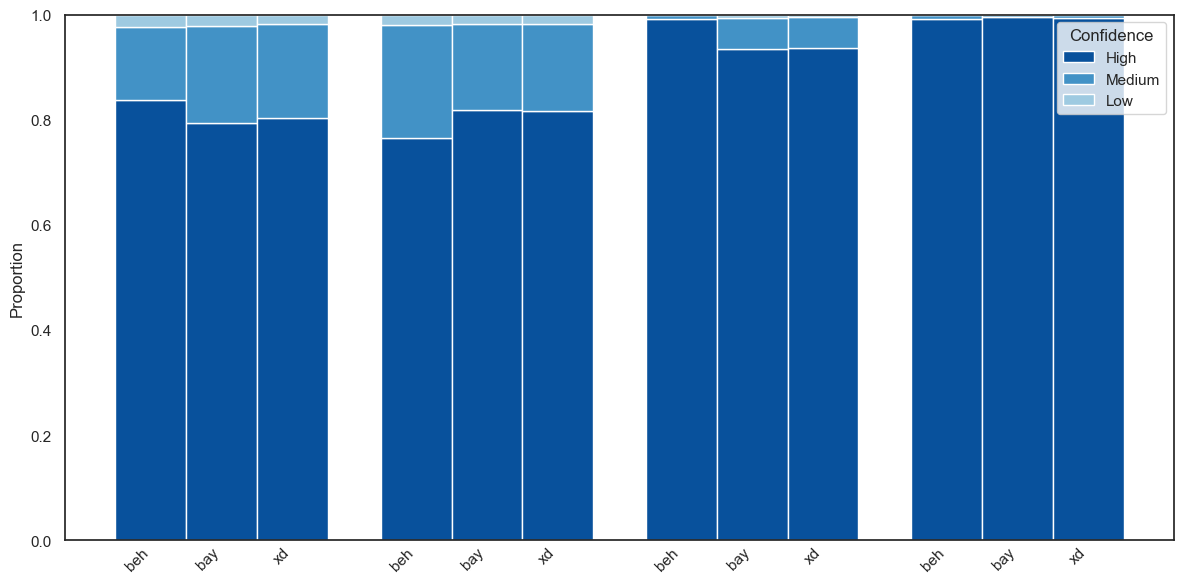

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.69642857 0.70535714 0.82366071 0.89285714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.25669643 0.25       0.16071429 0.10267857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.046875   0.04

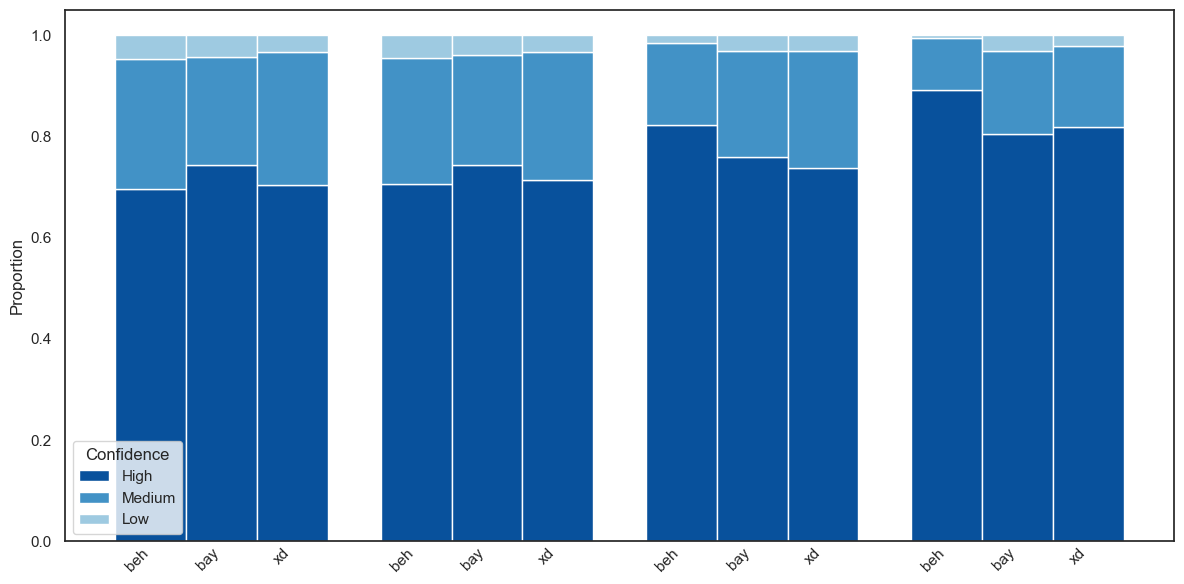

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.60714286 0.54315476 0.80580357 0.97767857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.30580357 0.27827381 0.12053571 0.01785714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.08705357 0.17

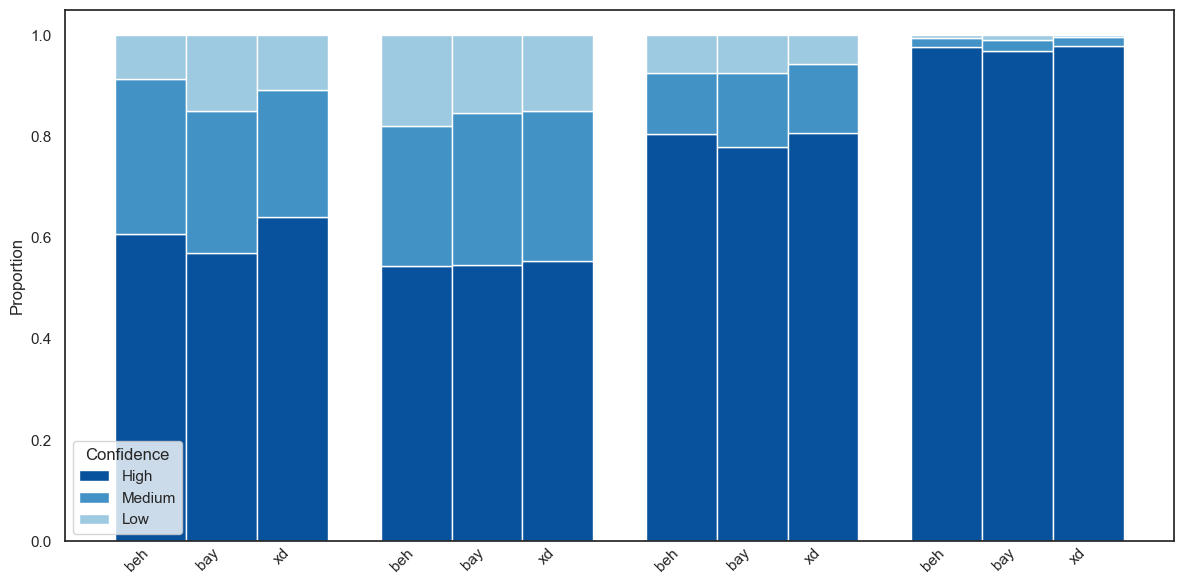

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.83035714 0.84375    0.8125     0.82142857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.13839286 0.10119048 0.11160714 0.10714286]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.03125    0.05

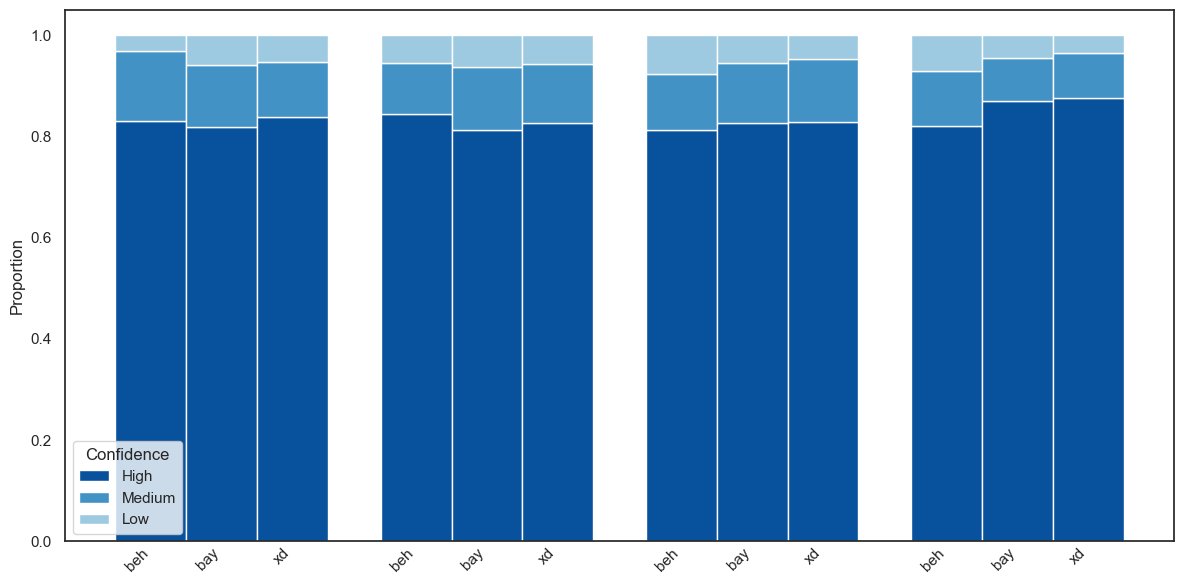

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.61160714 0.48065476 0.62053571 0.95535714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.36607143 0.35267857 0.22767857 0.04017857]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.02232143 0.16

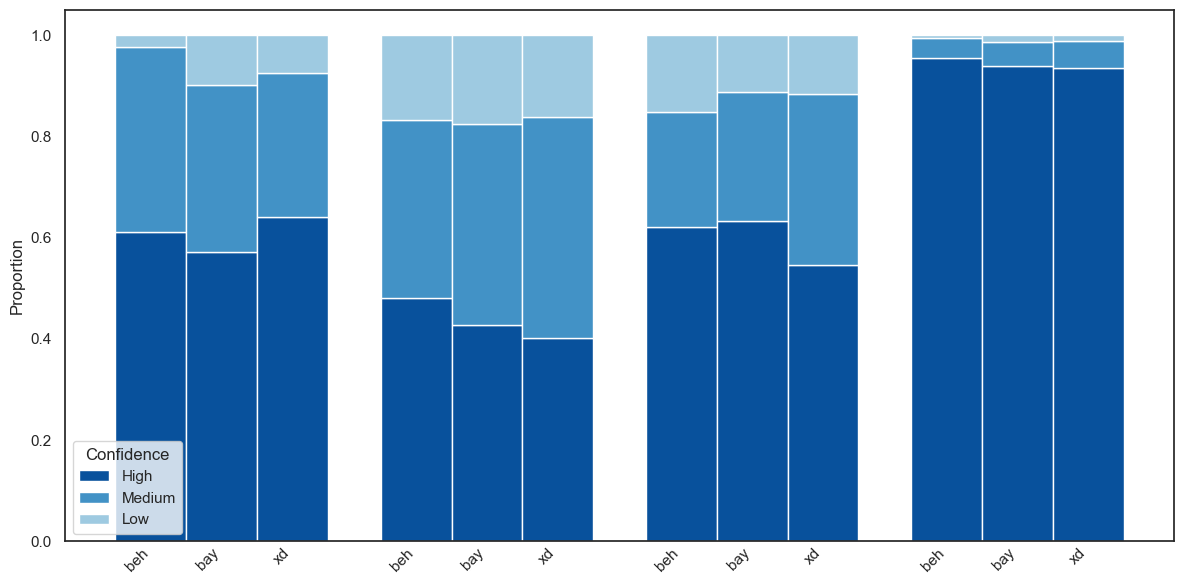

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.91964286 0.81845238 0.78571429 0.97321429]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.04017857 0.05059524 0.06026786 0.01785714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.04017857 0.13

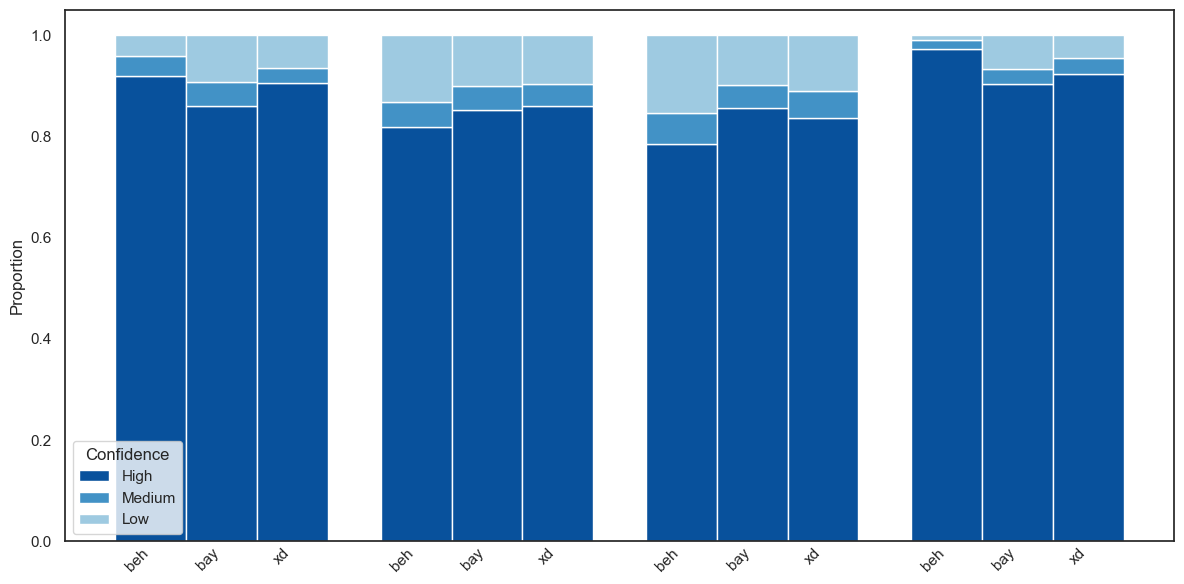

C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.83705357 0.75744048 0.83705357 0.9375    ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.12723214 0.17113095 0.13169643 0.05803571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_4188\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.03571429 0.07

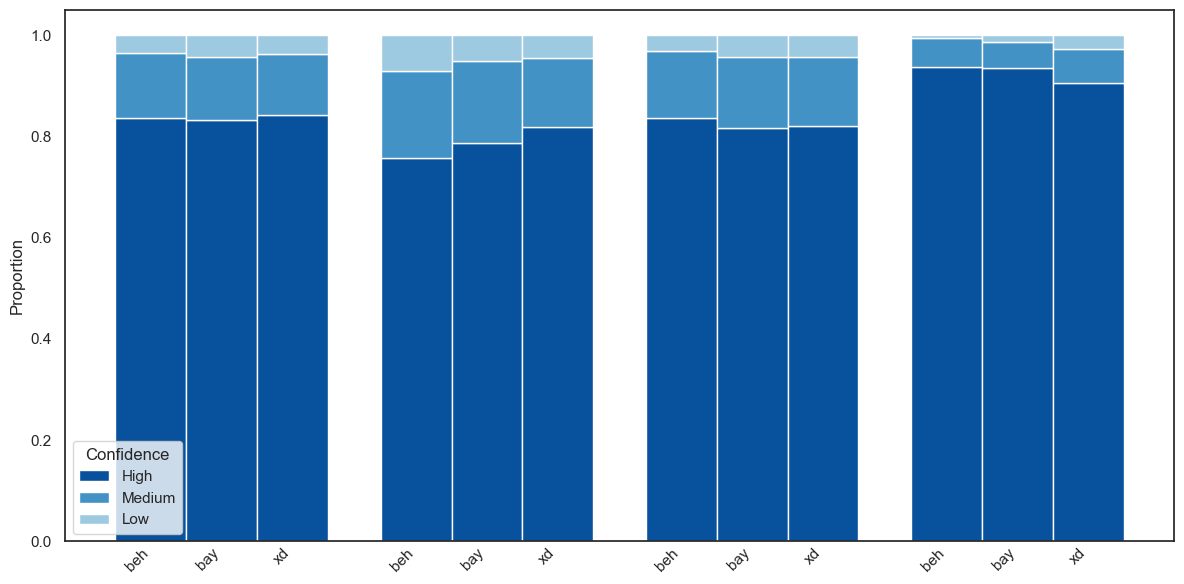

In [66]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}

for sub_id in sub_id_lst[6:]:

    df1 = compute_ratio(df_beh.loc[df_beh['sub_id'] == sub_id], 'beh', prop_total=False)
    df2 = compute_ratio(df_sim_bay.loc[df_sim_bay['sub_id'] == sub_id], 'bay', prop_total=False)
    df3 = compute_ratio(df_sim_xd.loc[df_sim_xd['sub_id'] == sub_id], 'xd', prop_total=False)

    df_count = pd.concat([df1, df2, df3], axis=0)
    df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

    categories = df_count['abs_del_VA'].unique()
    confidence = ['High', 'Medium', 'Low']

    x = np.arange(len(categories))
    width = 0.8 / len(names)


    fig, ax = plt.subplots(figsize=(12, 6))

    for i, name in enumerate(names):

        subset = df_count[df_count['Name'] == name]

        bottom = np.zeros(len(categories))

        for conf in confidence:

            values = (
                subset[subset['ConfLbl'] == conf]
                .set_index('abs_del_VA')
                .reindex(categories)['prop']
                .fillna(0)
                .values
            )

            ax.bar(
                x + (i - (len(names)-1)/2) * width,
                values,
                width,
                bottom=bottom,
                color=colors[conf],
                label=conf if i == 0 else None
            )

            bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

    ax.legend(title='Confidence')
    tick_positions = []
    tick_labels = []

    for i, name in enumerate(names):
        positions = x + (i - (len(names)-1)/2) * width
        
        tick_positions.extend(positions)
        tick_labels.extend([name] * len(categories))

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    #clean_axs(ax)
    ax.tick_params(axis='x', direction='in')

    plt.tight_layout()
    plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_dist_{sub_id}.png"), dpi=300)
    plt.show()


C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.20779221 0.37467018 0.79905437 0.96875   ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4025974  0.36147757 0.16312057 0.02232143]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.38961039 0

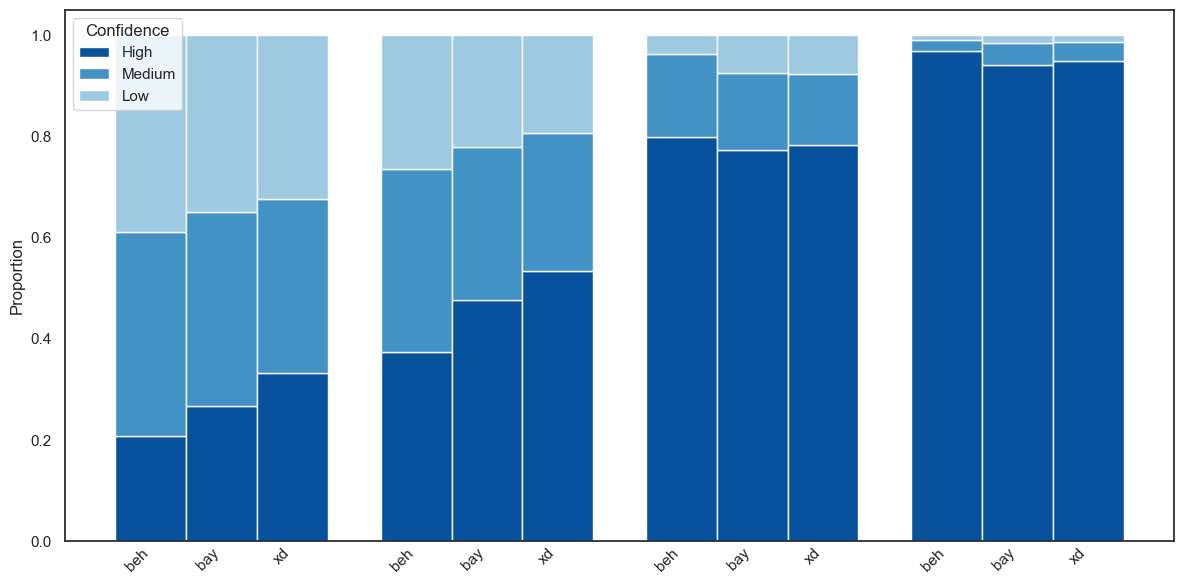

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.44444444 0.18       0.43706294 0.68656716]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.44444444 0.71       0.46153846 0.29850746]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11111111 0

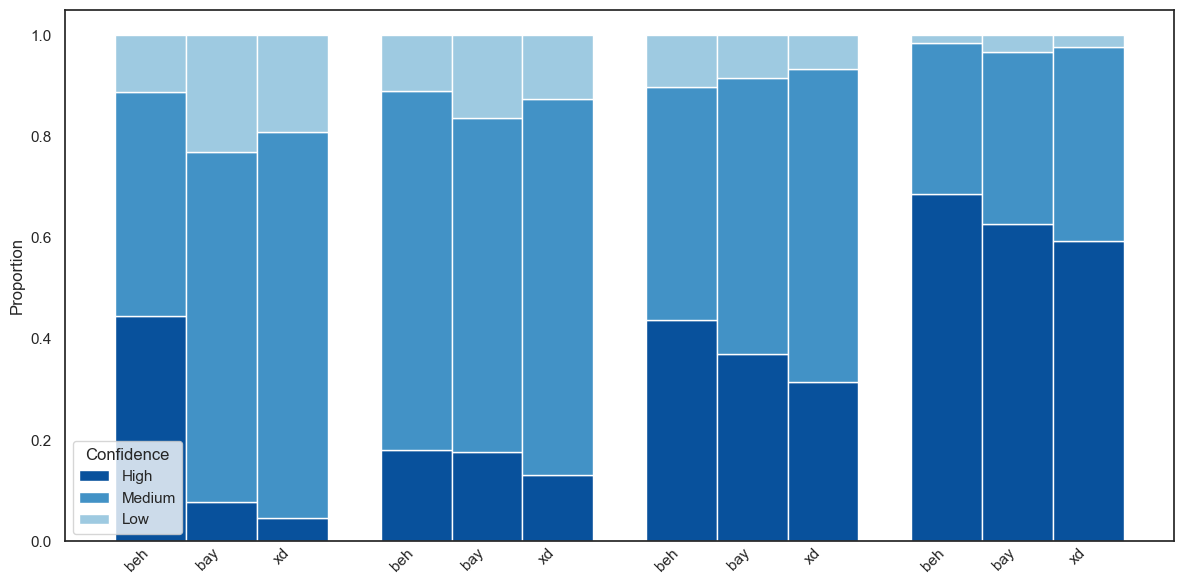

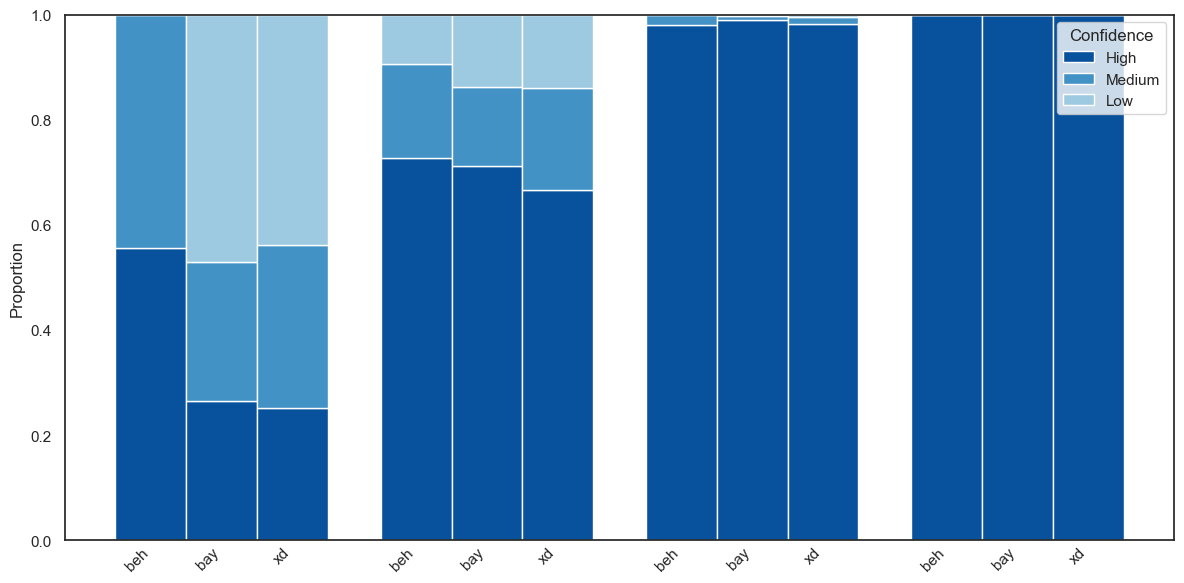

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.61219577 0.69036782 0.82125923 0.90993253]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.369885   0.29277894 0.17047083 0.0864585 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01791923 0

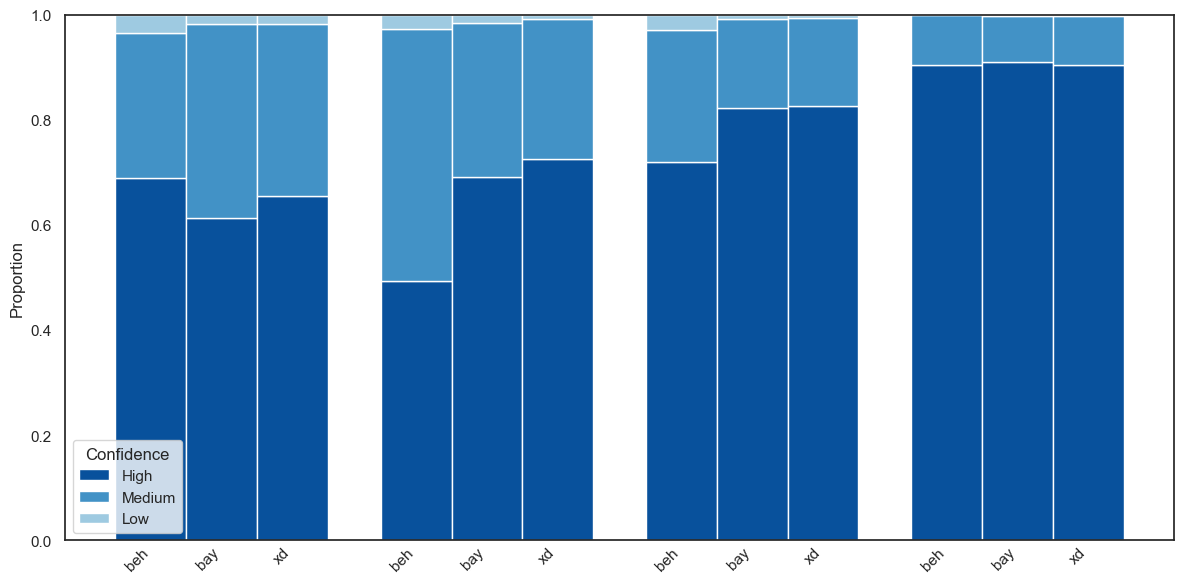

KeyError: 'Low'

In [6]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}

for sub_id in sub_id_lst:

    df1 = compute_ratio(df_beh.loc[(df_beh['sub_id'] == sub_id)&(df_beh['ComSourFlag']==2)], 'beh', prop_total=False)
    df2 = compute_ratio(df_sim_bay.loc[(df_sim_bay['sub_id'] == sub_id)&(df_sim_bay['R_pc']==2)], 'bay', prop_total=False)
    df3 = compute_ratio(df_sim_xd.loc[(df_sim_xd['sub_id'] == sub_id)&(df_sim_xd['R_pc']==2)], 'xd', prop_total=False)

    df_count = pd.concat([df1, df2, df3], axis=0)
    df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

    categories = df_count['abs_del_VA'].unique()
    confidence = ['High', 'Medium', 'Low']

    x = np.arange(len(categories))
    width = 0.8 / len(names)


    fig, ax = plt.subplots(figsize=(12, 6))

    for i, name in enumerate(names):

        subset = df_count[df_count['Name'] == name]

        bottom = np.zeros(len(categories))

        for conf in confidence:

            values = (
                subset[subset['ConfLbl'] == conf]
                .set_index('abs_del_VA')
                .reindex(categories)['prop']
                .fillna(0)
                .values
            )

            ax.bar(
                x + (i - (len(names)-1)/2) * width,
                values,
                width,
                bottom=bottom,
                color=colors[conf],
                label=conf if i == 0 else None
            )

            bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

    ax.legend(title='Confidence')
    tick_positions = []
    tick_labels = []

    for i, name in enumerate(names):
        positions = x + (i - (len(names)-1)/2) * width
        
        tick_positions.extend(positions)
        tick_labels.extend([name] * len(categories))

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    #clean_axs(ax)
    ax.tick_params(axis='x', direction='in')

    plt.tight_layout()
    plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_sep_dist_{sub_id}.png"), dpi=300)
    plt.show()


C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.40161725 0.23208191 0.08      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.4097035  0.39249147 0.36      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.18867925 0.37542662 0.56      ]'

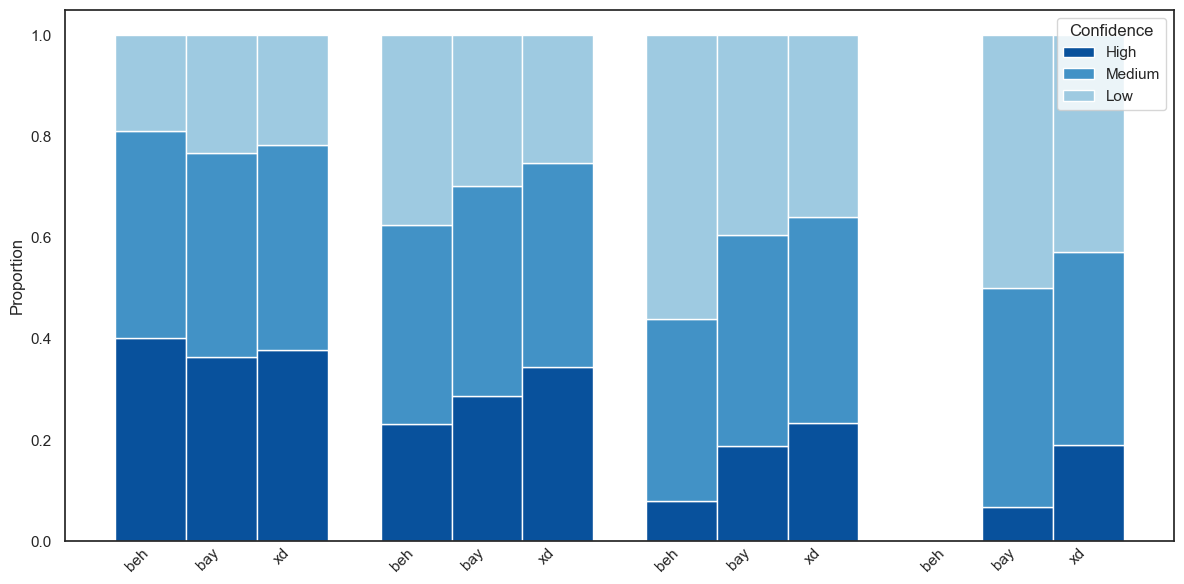

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.29157175 0.27797203 0.04320988 0.04347826]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.69248292 0.66608392 0.7345679  0.65217391]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01594533 0

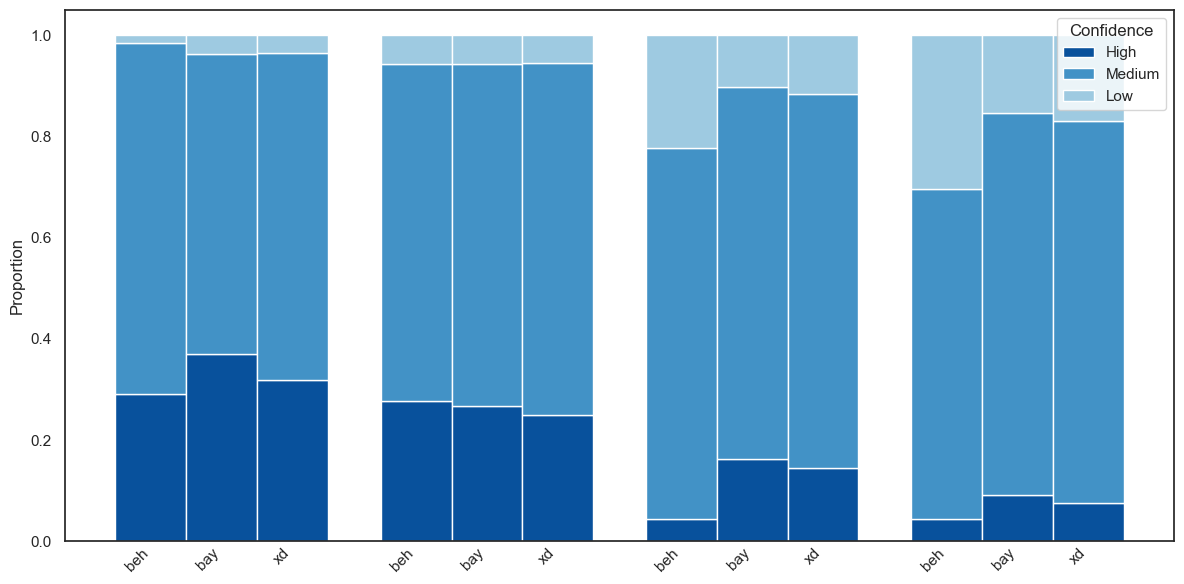

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.81162791 0.36440678 0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.15116279 0.21186441 0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0372093  0.42372881 0.66666667]'

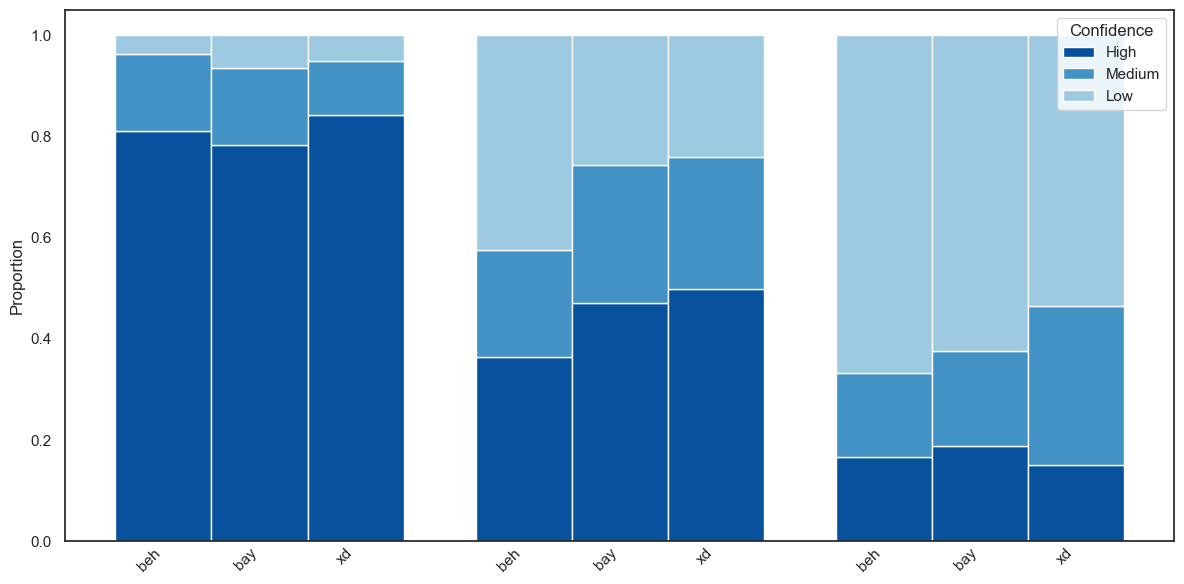

C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.82529973 0.80253292 0.76049632 0.7031346 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16825708 0.18940205 0.2317126  0.28457283]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_33544\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.00644319 0

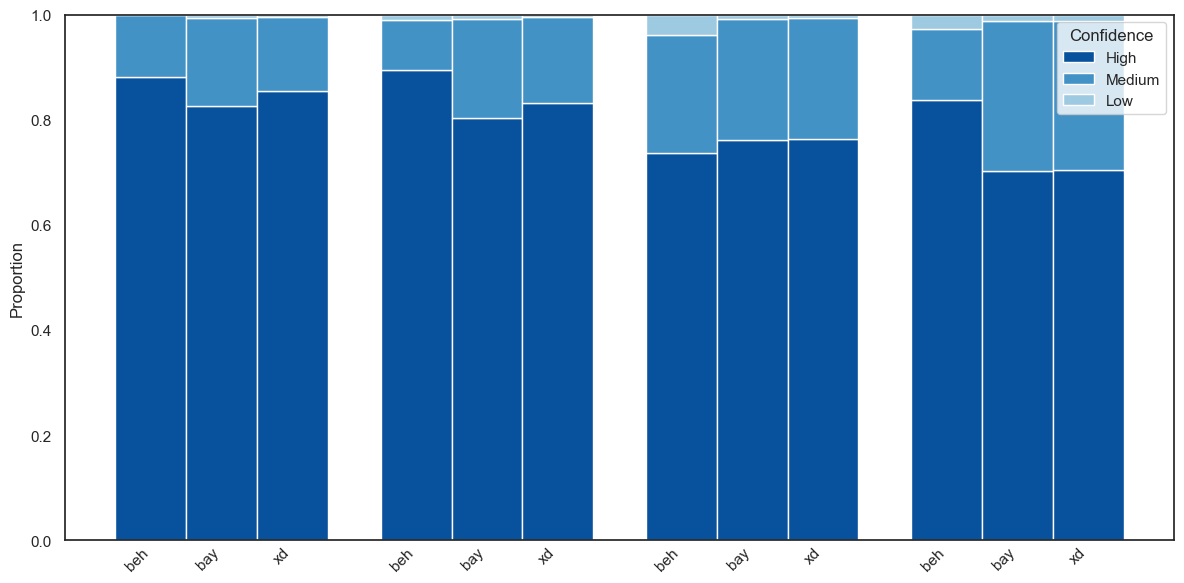

KeyError: 'Low'

In [7]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}

for sub_id in sub_id_lst:

    df1 = compute_ratio(df_beh.loc[(df_beh['sub_id'] == sub_id)&(df_beh['ComSourFlag']==1)], 'beh', prop_total=False)
    df2 = compute_ratio(df_sim_bay.loc[(df_sim_bay['sub_id'] == sub_id)&(df_sim_bay['R_pc']==1)], 'bay', prop_total=False)
    df3 = compute_ratio(df_sim_xd.loc[(df_sim_xd['sub_id'] == sub_id)&(df_sim_xd['R_pc']==1)], 'xd', prop_total=False)

    df_count = pd.concat([df1, df2, df3], axis=0)
    df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')

    categories = df_count['abs_del_VA'].unique()
    confidence = ['High', 'Medium', 'Low']

    x = np.arange(len(categories))
    width = 0.8 / len(names)


    fig, ax = plt.subplots(figsize=(12, 6))

    for i, name in enumerate(names):

        subset = df_count[df_count['Name'] == name]

        bottom = np.zeros(len(categories))

        for conf in confidence:

            values = (
                subset[subset['ConfLbl'] == conf]
                .set_index('abs_del_VA')
                .reindex(categories)['prop']
                .fillna(0)
                .values
            )

            ax.bar(
                x + (i - (len(names)-1)/2) * width,
                values,
                width,
                bottom=bottom,
                color=colors[conf],
                label=conf if i == 0 else None
            )

            bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

    ax.legend(title='Confidence')
    tick_positions = []
    tick_labels = []

    for i, name in enumerate(names):
        positions = x + (i - (len(names)-1)/2) * width
        
        tick_positions.extend(positions)
        tick_labels.extend([name] * len(categories))

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    #clean_axs(ax)
    ax.tick_params(axis='x', direction='in')

    plt.tight_layout()
    plt.savefig(os.path.join(work_path, "plot4paper",'sub_level', f"confidence_com_dist_{sub_id}.png"), dpi=300)
    plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.87914692 0.67352941 0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'High'] = df_count.loc[:, 'High'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.1042654  0.2        0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_count.loc[:, 'Medium'] = df_count.loc[:, 'Medium'] / df_count.loc[:, 'sum']
C:\Users\wenlou\AppData\Local\Temp\ipykernel_488\3637443290.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01658768 0.12647059 0.33333333]' has d

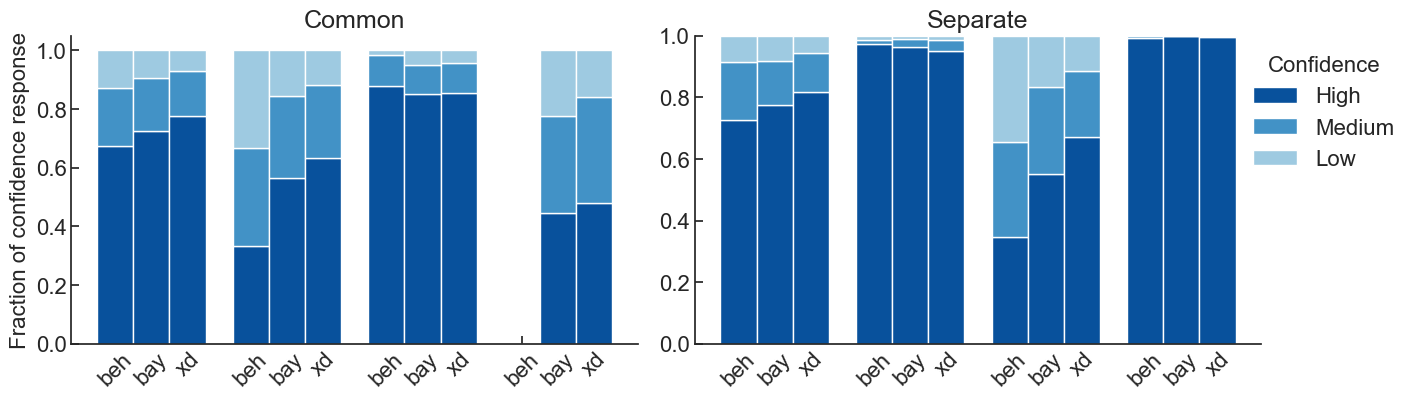

In [14]:
names = ['beh', 'bay', 'xd']
colors = {
    'High': '#08519C',    # dark blue
    'Medium': '#4292C6',  # medium blue
    'Low': '#9ECAE1'      # light blue
}

sub_id =34

def plot_confidence_distribution(sub_id, ax, com_f):
    # df1 = compute_ratio(df_beh.loc[df_beh['sub_id'] == sub_id], 'beh', prop_total=False)
    # df2 = compute_ratio(df_sim_bay.loc[df_sim_bay['sub_id'] == sub_id], 'bay', prop_total=False)
    # df3 = compute_ratio(df_sim_xd.loc[df_sim_xd['sub_id'] == sub_id], 'xd', prop_total=False)
    df1 = compute_ratio(df_beh.loc[(df_beh['sub_id'] == sub_id)&(df_beh['ComSourFlag']==com_f)], 'beh', prop_total=False)
    df2 = compute_ratio(df_sim_bay.loc[(df_sim_bay['sub_id'] == sub_id)&(df_sim_bay['R_pc']==com_f)], 'bay', prop_total=False)
    df3 = compute_ratio(df_sim_xd.loc[(df_sim_xd['sub_id'] == sub_id)&(df_sim_xd['R_pc']==com_f)], 'xd', prop_total=False)

    df_count = pd.concat([df1, df2, df3], axis=0)
    df_count = df_count.melt(id_vars=['abs_del_VA', 'Name'], value_vars=['High', 'Medium', 'Low'], var_name='ConfLbl', value_name='prop')
    for i, name in enumerate(names):

        subset = df_count[df_count['Name'] == name]
        bottom = np.zeros(len(categories))

        for conf in confidence:

            values = (
                subset[subset['ConfLbl'] == conf]
                .set_index('abs_del_VA')
                .reindex(categories)['prop']
                .fillna(0)
                .values
            )

            ax.bar(
                x + (i - (len(names)-1)/2) * width,
                values,
                width,
                bottom=bottom,
                color=colors[conf],
                label=conf if i == 0 else None
            )

            bottom += values
            

categories = df_beh['abs_del_VA'].unique()
confidence = ['High', 'Medium', 'Low']

x = np.arange(len(categories))
width = 0.8 / len(names)

fig, axs = plt.subplots(figsize=(14, 4), ncols = 2, gridspec_kw={'wspace': 0.1})
plot_confidence_distribution(sub_id=34, ax=axs[0], com_f=1)
plot_confidence_distribution(sub_id=34, ax=axs[1], com_f=2)

for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel('')
    ax.set_ylabel('')

    #ax.legend(title='Confidence')
    tick_positions = []
    tick_labels = []

    for i, name in enumerate(names):
        positions = x + (i - (len(names)-1)/2) * width
        
        tick_positions.extend(positions)
        tick_labels.extend([name] * len(categories))

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='center', fontsize=fontsize+2)
    #clean_axs(ax)
    #ax.tick_params(axis='x', direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='in', left=True, bottom=True, labelsize=fontsize)

axs[0].set_title('Common', fontsize=fontsize+2)
axs[1].set_title('Separate', fontsize=fontsize+2)
axs[0].set_ylabel('Fraction of confidence response', fontsize=fontsize)
axs[1].legend(title='Confidence', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', fontsize=fontsize, title_fontsize=fontsize)
#plt.tight_layout()
plt.subplots_adjust(left=0.05)
plt.savefig(os.path.join(work_path, "plot4paper",f"confidence_dist_{sub_id}.png"), dpi=300)
plt.show()
